## Grao en Intelixencia Artificial. USC. Curso 2025/2026
## VISION POR COMPUTADOR 

### TEMA 5: Segmentación de imaxe   

#### Limiarización (thresholding)

In [1]:
# # instalación da librería opencv https://pypi.org/project/opencv-python/
# !pip install opencv-python

In [1]:
!pwd

"pwd" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
images_path = '../images/'
import cv2
import sys
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

Para comezar imos visualizar a imaxe 'avocado.png' e comprobar que tipo de distribución ten.

In [4]:
im_av = cv2.imread(images_path + 'avocado.png', cv2.IMREAD_GRAYSCALE)
if im_av is None:
    sys.exit('Input image not found, check the path')

#### Visualización


Min and max pixel value =  4 , 255


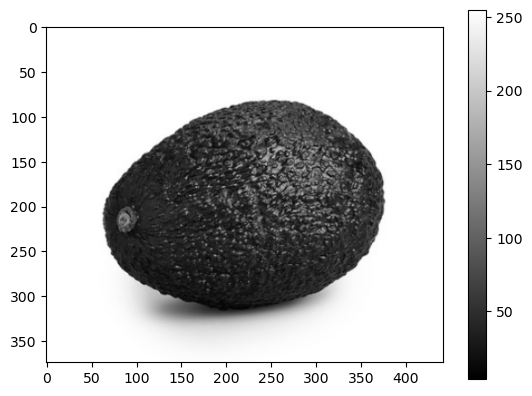

<Figure size 640x480 with 0 Axes>

In [5]:
print('Min and max pixel value = ', np.min(im_av), ',' , np.max(im_av))
plt.imshow(im_av, cmap='gray')
plt.colorbar()
plt.figure();

#### Cálculo do histograma:
- utilizando matplotlib e pyplot
- utilizando seaborn

In [ ]:
# usage: matplotlib.pyplot.hist(x, bins=None, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', 
#                               align='mid', orientation='vertical', rwidth=None, log=False, color=None, label=None, stacked=False, *, 
#                               data=None, **kwargs)
plt.hist(im_av.reshape(-1), 256, range=[0, 256]) 
plt.show();  

Podemos e debemos axustar o rango para visualizar mellor o histograma. Hai demasiados pixeles con valor 255 ou moi próximo (blanco) e iso crea ese pico tan alto que non deixa ver ben a outra parte. Que tipo de distribución é?

In [ ]:
plt.hist(im_av.reshape(-1), 250, range=[0, 250]) 
plt.show();  

Agora coa librería seaborn (sns). https://seaborn.pydata.org/index.html

**Limita de novo o rango para non ter o problema do pico en 255**

In [ ]:
# o teu código
sns.histplot(im_av.reshape(-1));

Que cambia? que opción sería mais útil para definir os limiares con maior precisión?

Tamén podemos calcular o KDE (Kernel Density Estimation): a distribución das observacions no conxunto de datos. O KDE representa os datos utilizando unha curva de densidade de probabilidade continua. Podémolo ver superposto ao histograma, ou de xeito independente.

In [ ]:
sns.histplot(im_av.reshape(-1), kde=True);

In [ ]:
sns.kdeplot(im_av.reshape(-1));       # só o kde

#### Algoritmo Otsu
**Exercicio 1:**
1. Que limiar de intensidade sería axeitado para segmentar o aguacate? hai un valor óptimo ou varios?
2. Segmenta o aguacate utilizando o algoritmo OTSU. Cal é o limiar óptimo estimado? ten sentido?

In [ ]:
# Otsu's thresholding
thresh, im_av_otsu = cv2.threshold(im_av, 0, 255, cv2.THRESH_OTSU)
print('Estimated optimal threshold =', thresh)
fig, ax = plt.subplots(1,2)
ax[0].imshow(im_av, cmap='gray'), ax[0].set_title('original image')
ax[1].imshow(im_av_otsu, cmap='gray'), ax[1].set_title('segmentation');

**Exercicio 2:**
Carga e visualiza a imaxe 'CT.png', e:
1. Inspecciona a distribución de intensidade dos pixels.
2. Que intensidade se debería utilizar para segmentar os pulmóns?
3. Intenta segmentalos utilizando o método Otsu. Cal é o limiar óptimo estimado?
4. Podemos utilizar este método para segmentar outra parte da imaxe, por exemplo os osos?
5. Se non, co visto ata agora, hai algunha forma de segmentalos?

In [ ]:
im_ct = cv2.imread(images_path + 'CT.png', cv2.IMREAD_GRAYSCALE)

if im_ct is None:
    sys.exit('Input image not found, check the path')

print('Min and max pixel value = ', np.min(im_ct), ',' , np.max(im_ct))
plt.imshow(im_ct, cmap='gray')
plt.colorbar()
plt.figure()
plt.hist(im_ct.reshape(-1), 256, range=[0, 256]), plt.show();

In [ ]:
# Otsu's thresholding
thresh, im_ct_otsu = cv2.threshold(im_ct, 0, 255, cv2.THRESH_OTSU)
print('Estimated optimal threshold =', thresh)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(im_ct, cmap='gray'), ax[0].set_title('original image'),
ax[1].imshow(im_ct_otsu, cmap='gray'), ax[1].set_title('segmentation');

#### Limiarización multi-nivel

**Exercicio 3:**
Aplica limiarización multi-nivel á imaxe 'plates.png'.   
1. Cal sería o número óptimo de limiares?
2. E os limiares óptimos?
3. Como cambia o histograma tras a limiarización? visualízao
4. E o KDE?

In [ ]:
im_plates = cv2.imread(images_path + 'plates.png', cv2.IMREAD_GRAYSCALE)
if im_plates is None:
    sys.exit('Input image not found, check the path')

In [ ]:
plt.imshow(im_plates, cmap='gray')
plt.colorbar();

plt.figure()
plt.hist(im_plates.reshape(-1), 256, range=[0,256]), plt.show()

sns.histplot(im_plates.reshape(-1), kde=True)

plt.figure(), sns.kdeplot(im_plates.reshape(-1));       # só kde

In [ ]:
#### O teu código

#### Modelos de Mestura Gaussiana (Gaussian Mixture Models (GMM))

**Exercicio 4:** Utilizando as funcións auxiliares proporcionadas a continuación:
1. Aplica o algoritmo GMM method (p.ex. a implementación scikit-learn) á imaxe 'CT.png' para segmentar **outras partes** da imaxe. Pista: podes facelo de forma secuencial, por exemplo utilizando inicialmente o método Otsu e despois GMM. 
3. Utilizando este método, sería posible segmentar os osos (partes mais blancas)?

In [ ]:
from sklearn import mixture
from scipy.stats import norm

In [ ]:
# Funcions auxiliares

def fit_GMM(im, nb_gaussians, plot_stds=False):
    """ Fit GMM given the desired nb of Gaussians """

    gmm = mixture.GaussianMixture(n_components=nb_gaussians, max_iter=1000, covariance_type='full', random_state=1).fit(im.reshape(-1, 1))
    ordered_mu, ordered_std, ordered_pi, order = find_GMM_statistics(gmm)
    gaussian_colors = ['b','g','r','c','m','y']    # max 6 gaussians, add more if necessary
    print('Means = ', ordered_mu)
    print('Stds = ', ordered_std)
    print('Pis = ', ordered_pi)
    for i in range(nb_gaussians):
        plot_gaussian_and_stds(np.array([np.min(im), np.max(im)]), ordered_mu[i], ordered_std[i], ordered_pi[i], gaussian_colors[i], plot_stds, alpha=0.8)
    
    return gmm, ordered_mu, ordered_std, ordered_pi, order

def find_GMM_statistics(gmm):
    """ Determine which one is the first (lower mean), the second, the third, etc., Gaussian to consistently color them in the plots, 
    visualize the masks, etc. """

    all_means = np.array(gmm.means_[:, 0]).flatten()
    all_covariances = gmm.covariances_.flatten()

    order = np.argsort(all_means)  # this is also the label of clusters, return also 'order', useful to modify the cluster's label if necessary
    ordered_mu = all_means[order]
    ordered_std = np.sqrt(all_covariances[order])
    ordered_pi = gmm.weights_[order]

    return ordered_mu, ordered_std, ordered_pi, order

def plot_gaussian_and_stds(gaussians_range, mu, std, pi, color, plot_stds=False, alpha=1):
    """ Plot the Gaussian given by mu, std and pi. If plot_stds, additionally plot vertical lines corresponding to +-1SD, +-2SD, +-3SD"""

    xmin, xmax = gaussians_range
    x = np.linspace(xmin, xmax, 1000)
    p = norm.pdf(x, mu, std) * pi
    if plot_stds:
        # plt.axvline(mu + std, 0, 1, label='pyplot vertical line', c=color)
        plt.axvline(mu + std, 0, 1, c=color, ls='--', alpha=0.75)
        plt.axvline(mu - std, 0, 1, c=color, ls='--', alpha=0.75)
    
        plt.axvline(mu + 2 * std, 0, 1, c=color, ls='-.', alpha=0.5)
        plt.axvline(mu - 2 * std, 0, 1, c=color, ls='-.', alpha=0.5)
    
        plt.axvline(mu + 3 * std, 0, 1, c=color, ls=':', alpha=0.25)
        plt.axvline(mu - 3 * std, 0, 1, c=color, ls=':', alpha=0.25)
    
    plt.plot(x, p, color, linewidth=2, alpha=alpha,
             label="Mean = {:.2f}; STD = {:.2f}; Weight = {:.2f}".format(mu, std, pi))

In [ ]:
other_colors = im_ct[np.where(im_ct_otsu==255)]      # exclude background and lungs
plt.hist(other_colors.reshape(-1), 256, range=[0, 256], density=True)    # density for probability density instead of total count 

gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=2, plot_stds=False)

plt.figure()
plt.hist(other_colors.reshape(-1), 256, range=[0, 256], density=True)
gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=3, plot_stds=False)

plt.figure()
plt.hist(other_colors.reshape(-1), 256, range=[0, 256], density=True)
gmm, ordered_mu, ordered_std, ordered_pi, order = fit_GMM(other_colors, nb_gaussians=4, plot_stds=False)

In [ ]:
#threshold = ??

bones_mask = np.zeros_like(im_ct)
bones_mask[np.where(im_ct > threshold)] = 1

fig, ax = plt.subplots(1, 2)
ax[0].imshow(im_ct, cmap='gray')
ax[1].imshow(bones_mask, cmap='gray');

#### Agrupamento (clustering)

**Exercicio 5:** Utilizando 'CT.png':
1. Utiliza **varias veces** o algoritmo k-means especificando o mesmo número de grupos (clusters).
2. Que diferencias, se as hai, observas en cada resultado?
3. Repite o mesmo variando o número de grupos. Que diferencias ves agora?

In [ ]:
# Using the scikit-learn library
n = 3      # nb of clusters

# Run 1
kmeans = KMeans(n_clusters=n, n_init="auto").fit(im_ct.reshape(-1, 1))
fig, ax = plt.subplots(1, 2)
ax[0].imshow(im_ct, cmap='gray')
ax[1].imshow(kmeans.labels_.reshape(im_ct.shape))

# plot image + labels overlayed
plt.figure()
plt.imshow(im_ct, cmap='gray')
plt.imshow(kmeans.labels_.reshape(im_ct.shape), alpha=0.2)
plt.colorbar()

# Run 2
kmeans = KMeans(n_clusters=n, n_init="auto").fit(im_ct.reshape(-1, 1))
fig, ax = plt.subplots(1, 2)
ax[0].imshow(im_ct, cmap='gray')
ax[1].imshow(kmeans.labels_.reshape(im_ct.shape))

plt.figure()
plt.imshow(im_ct, cmap='gray')
plt.imshow(kmeans.labels_.reshape(im_ct.shape), alpha=0.2)
plt.colorbar()

# Run 3
kmeans = KMeans(n_clusters=n, n_init="auto").fit(im_ct.reshape(-1, 1))
fig, ax = plt.subplots(1, 2)
ax[0].imshow(im_ct, cmap='gray')
ax[1].imshow(kmeans.labels_.reshape(im_ct.shape))

plt.figure()
plt.imshow(im_ct, cmap='gray')
plt.imshow(kmeans.labels_.reshape(im_ct.shape), alpha=0.2)
plt.colorbar()

In [ ]:
from sklearn.cluster import KMeans

**Exercicio 6:**
Carga e visualiza a imaxe 'fieldWheat.png'. Utiliza k-means (nb de clusters = 3) para segmentar:
1. O campo de trigo únicamente.
2. O ceo completo (parte azul + nubes)   
**Nota:** se hai mais dunha característica (p. ex. 'R', 'G', e 'B' nunha imax en cor), cada característica vai nunha columna.

In [ ]:
im_field = cv2.imread(images_path + 'field.png')      # cv2 reads it BGR order
if im_field is None:
    sys.exit('Input image not found, check the path')

plt.imshow(im_field[...,::-1])   # IMPORTANT --> matplotlib requires RGB order
plt.show()

In [ ]:
X = np.array([im_field[:, :, 0].reshape(-1), im_field[:, :, 1].reshape(-1), im_field[:, :, 2].reshape(-1)]).T
print(X.shape)

In [ ]:
kmeans = KMeans(n_clusters=3, n_init="auto").fit(X)
im_field_kmeans_labels = kmeans.labels_.reshape([im_field.shape[0], im_field.shape[1]])
fig, ax = plt.subplots(1, 2)
ax[0].imshow(im_field[...,::-1])  
ax[1].imshow(im_field_kmeans_labels)

plt.figure()
plt.imshow(im_field)
plt.imshow(im_field_kmeans_labels, alpha=0.4)
plt.colorbar()

print(kmeans.cluster_centers_)

#### O teu código